# Model Improvement After Feedback (10/09)

We show the desired outcome (**L1** and **L2** products on the full time series) with the continuous integration setup.  

To reduce the willingness of the data, we add a local filter which consider as outlier an observation based on the local delta distribution.

We will only consider the **forecasted data**, since the retroactive gapfilled data are identical.  

---

## Improvements

The improvements are the following:  

- adding a local filter to reduce the data willingness
- Including a multiplicative factor to avoid unwanted behavior  
- Testing the three different smoothing options


In [1]:
from IPython.display import IFrame, Image, display
import numpy as np
import math
import zarr
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import xarray as xr
import torch
import torch.nn as nn
import pandas as pd
from scipy.signal import savgol_filter
import gc
import imageio
from io import BytesIO
from affine import Affine
from functions import *

# not delete
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
import statsmodels.api as sm
import torch

This is the full gapfilled time serie with the smoothing using Savitzky Golay

In [2]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

random_pixels = 120  # pick one pixel index to check

ndvi_series = z[random_pixels, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.9,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.4, 0.8])


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:115: RuntimeWarning: divide by zero encountered in divide
  iqr_param = np.where(valid_ndvi / median_valid < 1, median_valid / valid_ndvi, valid_ndvi / median_valid)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:210: RuntimeWarning: divide by zero encountered in divide
  ratio = np.maximum(valid_ndvi, median_valid) / np.minimum(valid_ndvi, median_valid)


In [3]:


# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[random_pixels, :]  
dates = ds["dates"].values   # numpy datetime64



# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)



# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = np.nan
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [4]:
# --- run your function row by row ---
# need an inital condition
last_date = None#pd.Timestamp("2018-04-25")
last_potential_dates = []
deltas_arr = []
dates_delta_arr = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr = ndvi_continous_final(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_dates = last_potential_dates,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7
    )


/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:718: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[date, "outlier"] = True


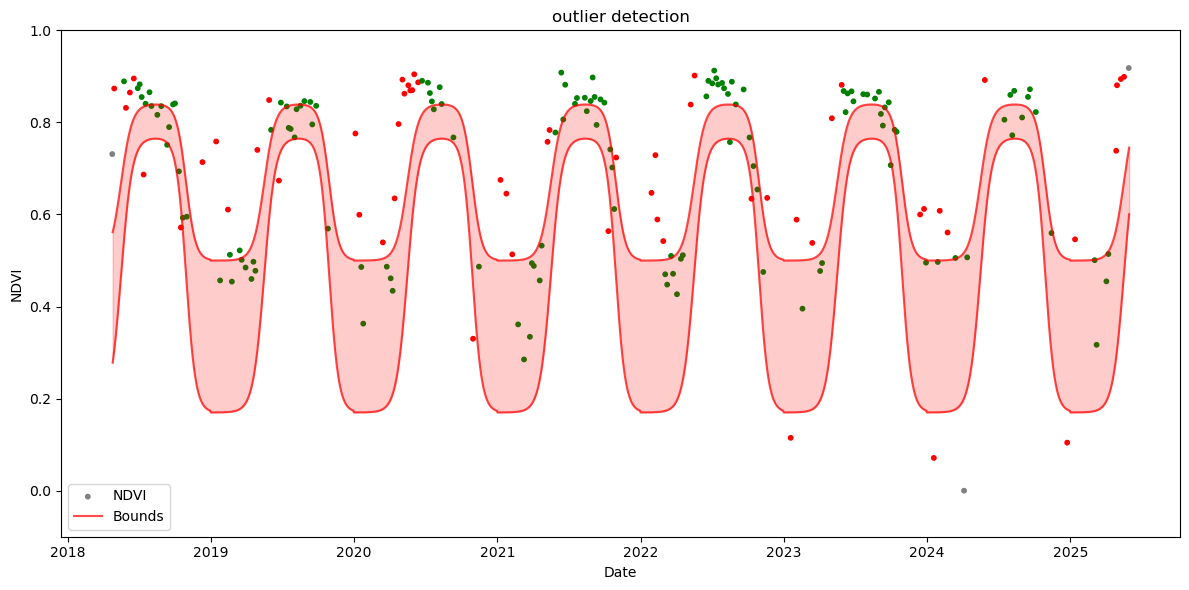

In [5]:

# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()



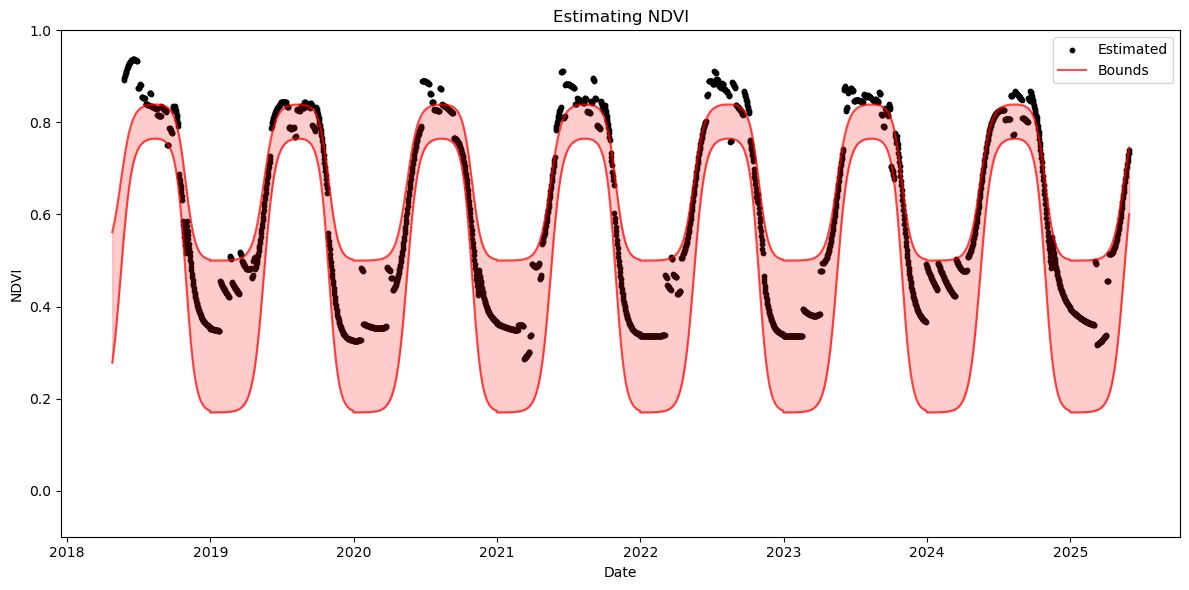

In [6]:

# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Estimating NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

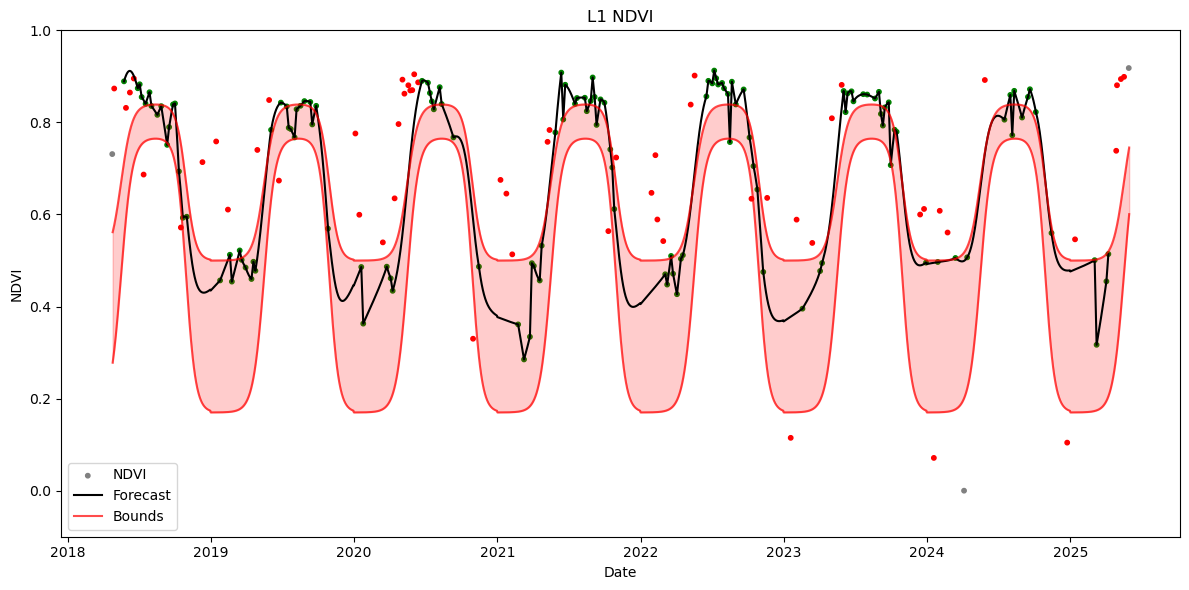

In [7]:
# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

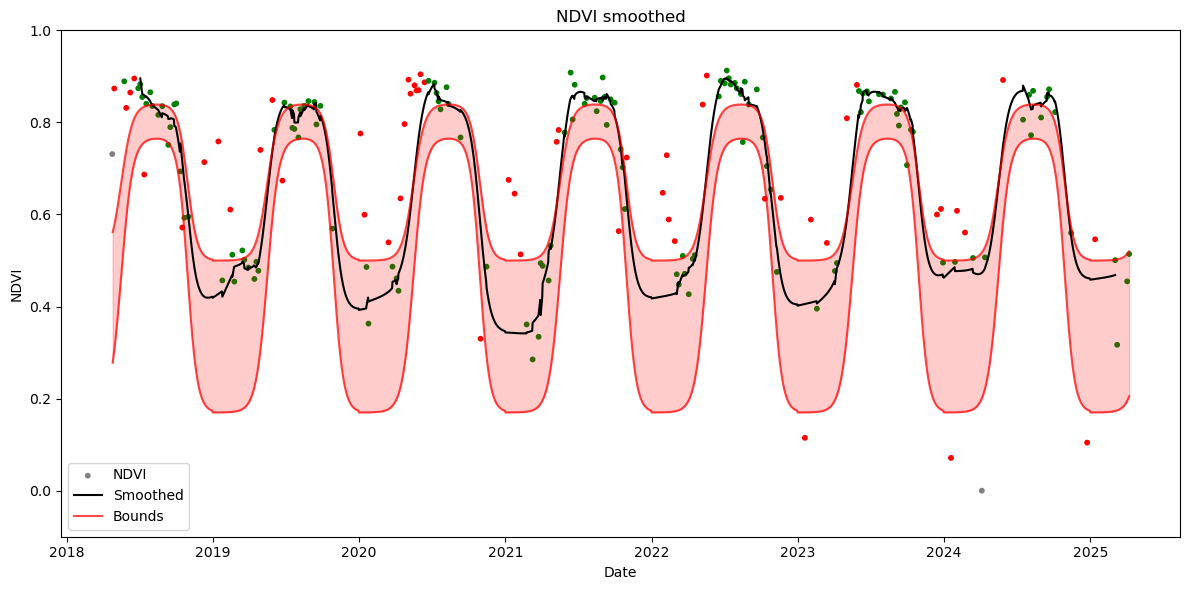

In [8]:
# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

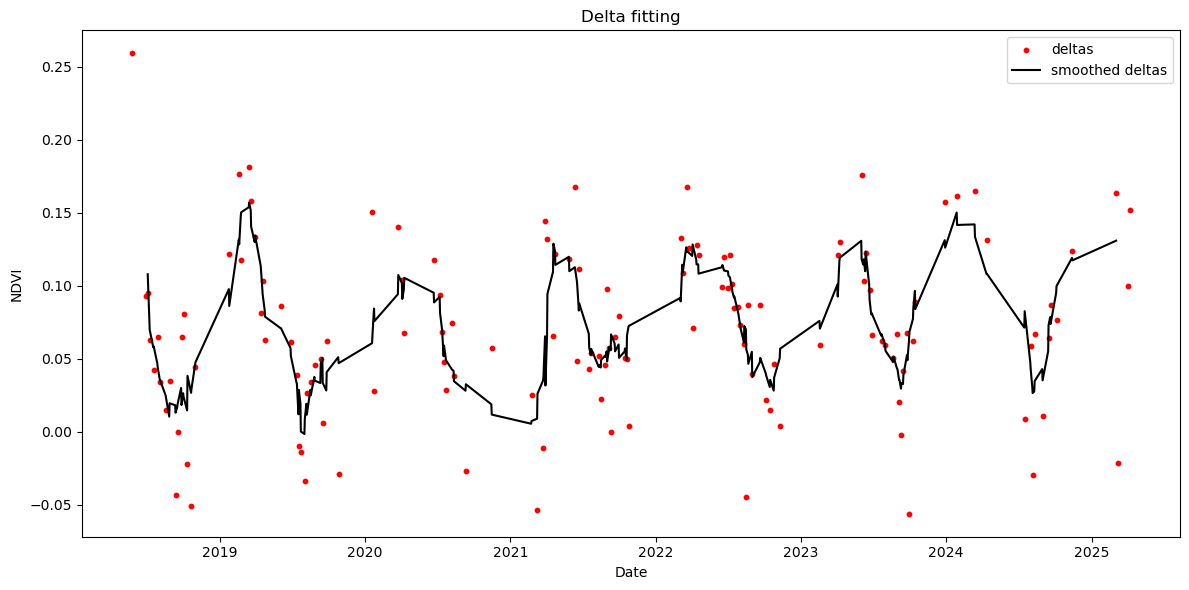

In [9]:
# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]
mask = (df["deltas"].notna()) & (df["outlier"] == False)


fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.scatter(df_plot.index, df_plot["deltas"], label = "deltas",color='red', s= 10)
ax.plot(df_plot.index, df_plot["delta_smoothed"], label = "smoothed deltas", color='black')


ax.set_title("Delta fitting")
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()